# 3-3 좀 더 복잡한 분류 문제

본 노트북은 본문 3-3 절의 코드 예제([코드 3-8] ~ [코드 3-29])를 절 흐름 그대로 모은 것이다. 회오리 모양으로 분포한 3 클래스 데이터를 다층 퍼셉트론으로 분류한다.

다루는 내용
- CSV 데이터 로딩과 훈련/평가 분할
- 원-핫 인코딩과 다중 클래스 분류
- `nn.Sequential` 의 다양한 활용법 (위치/이름/블록)
- 모델 학습과 분류 정확도 평가 (`get_accuracy`)
- 교차 엔트로피 손실 함수와 ReLU 활성화 함수로의 단계적 개선

In [1]:
# 참고 - 환경 설정 (code_reference 모듈 임포트 경로와 시각화 설정)
import sys
sys.path.append('../../')

from code_reference import common
# viz.configure()에서 save_grayscale=True로 지정하면 노트북에 표시되는 시각화 이미지를 파일로 저장함
from code_reference import visualize as viz

common.set_korean_plot_env()
viz.configure(save_grayscale=False)

## 라이브러리 import 와 시드 고정

In [2]:
# 참고 - 라이브러리 import 와 시드 고정
import csv
import random
import time
from collections import OrderedDict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchinfo import summary

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## [코드 3-8] CSV 형식 파일의 데이터로 텐서 생성

파이썬 표준 라이브러리의 `csv` 모듈로 회오리 데이터를 리스트로 읽고, 텐서로 변환한 뒤 6:4 비율로 훈련용/평가용 데이터로 나눈다.

> 참고: 본문 경로는 `'../data/ch3_spiral_data.csv'` 이지만, 노트북은 `notebooks/ch03/` 에 위치하므로 `'../../data/ch3_spiral_data.csv'` 가 정확하다. (이 경로 차이는 `_book` 에 기록한다.)

In [3]:
# 코드 3-8 - CSV 형식 파일의 데이터로 텐서 생성

X_list, Y_list = [], []
with open('../../data/ch3_spiral_data.csv', 'r') as f:
    # csv.DictReader 객체로 루프를 만들어 사용 (열 이름이 명시된 머리줄이 있는 경우)
    # 머리줄이 없는 경우 csv.reader 를 사용해야 함
    reader = csv.DictReader(f)              # 머리줄을 열 이름으로 자동 처리
    print(type(reader))                     # csv.DictReader 객체
    for row in reader:                      # row - 각 데이터 샘플의 딕셔너리
        X_list.append([float(row['x1']), float(row['x2'])])
        Y_list.append(int(row['label']))

# 리스트를 텐서로 변환
X = torch.tensor(X_list)                    # (900, 2) 형태의 텐서
Y = torch.tensor(Y_list)                    # (900,) 형태의 텐서

# 데이터를 6:4 비율로 훈련용 데이터(X_train, Y_train)와 평가용 데이터(X_test, Y_test)로 나눔
train_size = int(len(Y) * 0.6)              # 훈련 데이터 샘플 수
X_train = X[:train_size]                    # 훈련 데이터 (입력)
Y_train = Y[:train_size]                    # 훈련 데이터 (정답)
X_test = X[train_size:]                     # 평가 데이터 (입력)
Y_test = Y[train_size:]                     # 평가 데이터 (정답)

print(f'전체 샘플 수: {len(X)}')
print(f'훈련 샘플 수: {len(X_train)}, 평가 샘플 수: {len(X_test)}')

<class 'csv.DictReader'>
전체 샘플 수: 900
훈련 샘플 수: 540, 평가 샘플 수: 360


## [그림 3-10] 대응 — 회오리 데이터 분포 시각화

데이터 분포를 클래스별 색·기호로 표시한다.

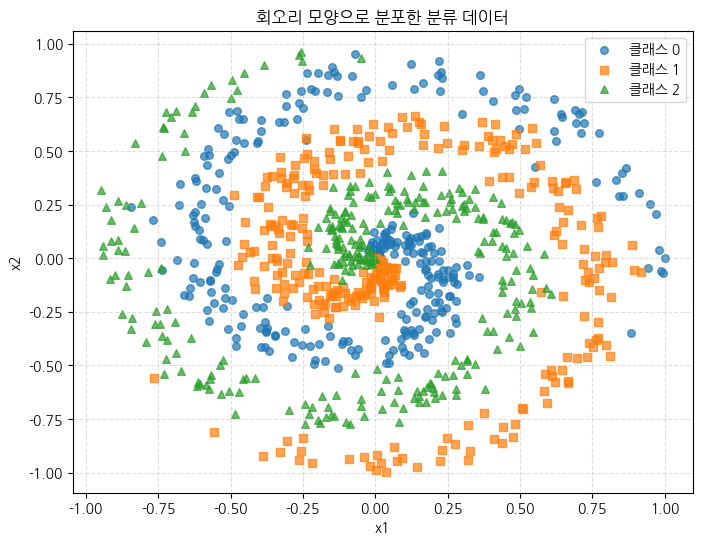

In [4]:
# 참고 - 데이터 분포 시각화 ([그림 3-10])

viz.plot_scatter(
    X, Y,
    class_names=['클래스 0', '클래스 1', '클래스 2'],
    title='회오리 모양으로 분포한 분류 데이터',
    x_label='x1', y_label='x2',
)

## [코드 3-9] 파이토치의 원-핫 인코딩 함수 `F.one_hot()`

정수형 클래스 인덱스를 `F.one_hot()` 으로 원-핫 벡터로 인코딩한다. `num_classes` 인자로 벡터 크기를 지정한다.

In [5]:
# 코드 3-9 - 파이토치의 원-핫 인코딩 함수 one_hot()

# torch.nn.functional 패키지는 보통 F라는 별칭으로 import함
import torch.nn.functional as F

class_1 = torch.tensor([1])
class_all = torch.tensor([0, 1, 2])

print(f'클래스가 3개일 때 두 번째 클래스의 원-핫 벡터: {F.one_hot(class_1, num_classes=3)}')
print(f'클래스가 4개일 때 두 번째 클래스의 원-핫 벡터: {F.one_hot(class_1, num_classes=4)}')

# 여러 클래스의 원-핫 벡터를 한 번에 만들면 차원이 하나 더 늘어난다. (3,) -> (3, 3)
print(f'클래스가 3개일 때 모든 클래스의 원-핫 벡터:\n{F.one_hot(class_all, num_classes=3)}')  # (3,) -> (3, 3)

클래스가 3개일 때 두 번째 클래스의 원-핫 벡터: tensor([[0, 1, 0]])
클래스가 4개일 때 두 번째 클래스의 원-핫 벡터: tensor([[0, 1, 0, 0]])
클래스가 3개일 때 모든 클래스의 원-핫 벡터:
tensor([[1, 0, 0],
        [0, 1, 0],
        [0, 0, 1]])


## [코드 3-10] 정답 데이터를 원-핫 텐서로 변경

`nn.MSELoss` 는 실수형 텐서를 인자로 받으므로 `.float()` 로 변환한다.

In [6]:
# 코드 3-10 - 정답 데이터를 원-핫 텐서로 변경
Y_train_onehot = F.one_hot(Y_train, num_classes=3).float()  # (540,) -> (540, 3)
Y_test_onehot = F.one_hot(Y_test, num_classes=3).float()    # (360,) -> (360, 3)

print(f'Y_train_onehot 형태: {Y_train_onehot.shape}')
print(f'Y_test_onehot  형태: {Y_test_onehot.shape}')

Y_train_onehot 형태: torch.Size([540, 3])
Y_test_onehot  형태: torch.Size([360, 3])


## [코드 3-11] 두 개의 은닉층을 가진 다층 퍼셉트론 모델 정의

64 개의 뉴런을 가진 은닉층 두 개를 갖는 `SpiralMLP` 클래스이다.

In [7]:
# 코드 3-11 - 두 개의 은닉층을 가진 다층 퍼셉트론 모델 정의

# 두 개의 은닉층과 하나의 출력층으로 구성된 다층 퍼셉트론 모델 클래스
class SpiralMLP(nn.Module):
    # 세 개의 선형 계층과 하나의 활성화 함수 계층 정의
    def __init__(self, hidden_dim):
        super().__init__()
        self.hidden_layer1 = nn.Linear(2, hidden_dim)           # 은닉층 1
        self.hidden_layer2 = nn.Linear(hidden_dim, hidden_dim)  # 은닉층 2
        self.output_layer = nn.Linear(hidden_dim, 3)            # 출력층
        self.activation = nn.Sigmoid()                          # 활성화 계층 (세 곳에 재사용)

    # 두 은닉층과 출력층을 거쳐 모델의 출력을 반환하는 forward() 메서드
    def forward(self, x):
        x = self.hidden_layer1(x)       # (N, 2) -> (N, 64) (N은 샘플의 수, hidden_dim=64)
        x = self.activation(x)
        x = self.hidden_layer2(x)       # (N, 64) -> (N, 64)
        x = self.activation(x)
        x = self.output_layer(x)        # (N, 64) -> (N, 3)
        x = self.activation(x)
        return x

HIDDEN_DIM = 64                         # 은닉층 뉴런의 수
model = SpiralMLP(HIDDEN_DIM)

print(model)

SpiralMLP(
  (hidden_layer1): Linear(in_features=2, out_features=64, bias=True)
  (hidden_layer2): Linear(in_features=64, out_features=64, bias=True)
  (output_layer): Linear(in_features=64, out_features=3, bias=True)
  (activation): Sigmoid()
)


## [코드 3-12] `nn.Sequential` 로 모델 정의

동일한 구조를 더 간결하게 만들 수 있다. 계층 객체를 데이터 흐름 순서대로 인자로 전달한다.

In [8]:
# 코드 3-12 - nn.Sequential 로 모델 정의

# 모델 구성 계층 객체를 데이터 흐름 순서대로 인자로 전달해 모델 생성
# 클래스(nn.Linear)가 아닌 객체(nn.Linear())를 인자로 전달하며, 계층 객체의 수는 제한이 없음
model = nn.Sequential(
    nn.Linear(2, HIDDEN_DIM),
    nn.Sigmoid(),
    nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
    nn.Sigmoid(),
    nn.Linear(HIDDEN_DIM, 3),
    nn.Sigmoid(),
)

# 모델 구조 확인
summary(model, input_size=(540, 2), device='cpu')

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [540, 3]                  --
├─Linear: 1-1                            [540, 64]                 192
├─Sigmoid: 1-2                           [540, 64]                 --
├─Linear: 1-3                            [540, 64]                 4,160
├─Sigmoid: 1-4                           [540, 64]                 --
├─Linear: 1-5                            [540, 3]                  195
├─Sigmoid: 1-6                           [540, 3]                  --
Total params: 4,547
Trainable params: 4,547
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 2.46
Input size (MB): 0.00
Forward/backward pass size (MB): 0.57
Params size (MB): 0.02
Estimated Total Size (MB): 0.59

## [코드 3-13] 미리 만들어둔 계층 리스트를 언패킹으로 전달

리스트로 만든 계층 묶음을 언패킹(`*layers`) 으로 전달한다. 리스트·튜플을 직접 인자로 전달하면 예외가 발생한다.

In [9]:
# 코드 3-13 - 미리 만들어둔 계층 리스트를 언패킹으로 전달

layers = [
    nn.Linear(2, HIDDEN_DIM),
    nn.Sigmoid(),
    nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
    nn.Sigmoid(),
    nn.Linear(HIDDEN_DIM, 3),
    nn.Sigmoid(),
]

# nn.Sequential(layers) 와 같이 언패킹 없이 인자로 사용하면 예외 발생
model = nn.Sequential(*layers)

print(f'모델 계층 수: {len(model)}')

모델 계층 수: 6


## [코드 3-14] `nn.Sequential` 객체에서 계층의 삭제와 추가

`pop()`, `insert()` 메서드로 계층을 교체할 수 있다.

In [10]:
# 코드 3-14 - nn.Sequential 객체에서 계층의 삭제와 추가
# 출력층 뉴런의 수를 3 에서 2 로 바꾸기 위해 새로운 계층 객체로 갈아 끼우는 경우
output_layer = model.pop(4)                 # model[4] 계층을 제거하고 반환
new_output_layer = nn.Linear(HIDDEN_DIM, 2)
model.insert(4, new_output_layer)           # model[4] 위치에 new_output_layer 삽입
print(model)

Sequential(
  (0): Linear(in_features=2, out_features=64, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=64, out_features=64, bias=True)
  (3): Sigmoid()
  (4): Linear(in_features=64, out_features=2, bias=True)
  (5): Sigmoid()
)


## [코드 3-15] 인덱싱으로 계층 객체에 접근하기

구성 순서에 따른 인덱싱으로 계층 객체에 접근할 수 있다.

> 위 [코드 3-14] 에서 출력층을 `(HIDDEN_DIM, 2)` 로 바꿔 두었으므로, 이후 셀들을 위해 원래 구조의 모델을 다시 생성한다.

In [11]:
# 참고 - 원본 구조의 모델 재생성 (다음 셀들에서 사용)

model = nn.Sequential(
    nn.Linear(2, HIDDEN_DIM),
    nn.Sigmoid(),
    nn.Linear(HIDDEN_DIM, HIDDEN_DIM),
    nn.Sigmoid(),
    nn.Linear(HIDDEN_DIM, 3),
    nn.Sigmoid(),
)

In [12]:
# 코드 3-15 - 인덱싱으로 계층 객체에 접근하기

layer_0 = model[0]      # 첫 번째 계층((0): Linear(in_features=2, out_features=64, bias=True))
layer_3 = model[3]      # 네 번째 계층((3): Sigmoid())
layer_last = model[-1]  # 마지막 계층((5): Sigmoid())
print(f'첫 번째 은닉층: {layer_0}')
print(f'두 번째 활성화 계층: {layer_3}')
print(f'마지막 계층: {layer_last}')


첫 번째 은닉층: Linear(in_features=2, out_features=64, bias=True)
두 번째 활성화 계층: Sigmoid()
마지막 계층: Sigmoid()


## [코드 3-16] 계층마다 적절한 이름을 붙여 모델 만들기

`OrderedDict` 로 (이름, 계층 객체) 쌍을 전달하면 계층에 이름을 붙이고, 이름을 키로 사용해 계층 객체에 접근할 수 있다.

In [13]:
# 코드 3-16 - 계층마다 적절한 이름을 붙여 모델 만들기

# (이름, 계층 객체) 튜플의 리스트를 사용해 OrderedDict 객체 생성
layers_ordered_dict = OrderedDict([
    ('hidden_1', nn.Linear(2, HIDDEN_DIM)),
    ('activation_1', nn.Sigmoid()),
    ('hidden_2', nn.Linear(HIDDEN_DIM, HIDDEN_DIM)),
    ('activation_2', nn.Sigmoid()),
    ('output', nn.Linear(HIDDEN_DIM, 3)),
    ('activation_3', nn.Sigmoid()),
])

# OrderedDict 객체를 인자로 모델 생성
model = nn.Sequential(layers_ordered_dict)
print(model)                                        # 계층의 이름을 함께 출력
print(f'세 번째 활성화 계층: {model.activation_3}')  # 인덱싱이 아닌 . 표기법 사용
print(f'마지막 계층: {model[-1]}')                   # 순서 기준 인덱싱도 가능

Sequential(
  (hidden_1): Linear(in_features=2, out_features=64, bias=True)
  (activation_1): Sigmoid()
  (hidden_2): Linear(in_features=64, out_features=64, bias=True)
  (activation_2): Sigmoid()
  (output): Linear(in_features=64, out_features=3, bias=True)
  (activation_3): Sigmoid()
)
세 번째 활성화 계층: Sigmoid()
마지막 계층: Sigmoid()


## [코드 3-17] 계층 객체를 이름과 함께 추가

`add_module()` 메서드로 모델의 마지막에 이름을 지정해 계층을 추가한다.

In [14]:
# 코드 3-17 - 계층 객체를 이름과 함께 추가

model.add_module('real_output', nn.Linear(3, 2))
print(model[-1])            

Linear(in_features=3, out_features=2, bias=True)


## [코드 3-18] 계층의 묶음 블록을 정의하고, 이를 사용해 모델 만들기

`nn.Sequential` 클래스를 상속해 재사용 가능한 계층 묶음 블록을 만들고, 이를 조립해 모델을 정의한다.

In [15]:
# 코드 3-18 - 계층의 묶음 블록을 정의하고, 이를 사용해 모델 만들기

# 선형 계층과 활성화 계층을 묶은 계층 블록 클래스
class MLPComponentBlock(nn.Sequential):
    # 계층 묶음 블록 속 각 계층의 인자는 상황에 따라 값이 바뀔 수 있음. 
    # 이런 값들은 생성자의 인자로 받아 계층 묶음 블록을 유연하게 정의    
    def __init__(self, in_features, out_features):
        # super()는 nn.Module이 아닌 nn.Sequential이므로, nn.Sequential의 생성 방법을 따름
        super().__init__(
            nn.Linear(in_features, out_features),
            nn.Sigmoid(),
        )
    # nn.Sequential 의 파생 클래스는 forward() 메서드를 생략해도 됨 (필요한 경우만 추가)


# 정의한 계층 블록 클래스(MLPComponentBlock)를 사용해 모델 정의
class SpiralMLP(nn.Module):
    # nn. 클래스 대신 정의한 계층 블록 클래스로 계층 객체 생성
    def __init__(self, hidden_dim):
        super().__init__()
        self.hidden_block1 = MLPComponentBlock(2, hidden_dim)
        self.hidden_block2 = MLPComponentBlock(hidden_dim, hidden_dim)
        self.output_block = MLPComponentBlock(hidden_dim, 3)

    def forward(self, x):
        x = self.hidden_block1(x)
        x = self.hidden_block2(x)
        x = self.output_block(x)
        return x


model = SpiralMLP(HIDDEN_DIM)
print(model)

SpiralMLP(
  (hidden_block1): MLPComponentBlock(
    (0): Linear(in_features=2, out_features=64, bias=True)
    (1): Sigmoid()
  )
  (hidden_block2): MLPComponentBlock(
    (0): Linear(in_features=64, out_features=64, bias=True)
    (1): Sigmoid()
  )
  (output_block): MLPComponentBlock(
    (0): Linear(in_features=64, out_features=3, bias=True)
    (1): Sigmoid()
  )
)


## 학습 함수 정의 (`train_with_loss`)

본문 [코드 3-19] 는 `train_with_loss(model, X_train, Y_train_onehot, criterion, optimizer, epochs)` 를 호출한다. 본 노트북에서는 이 학습 함수를 한 번 정의한 뒤 이번 절 내내 재사용한다. 학습 로그는 공통 표준인 `common.EpochLogger` 로 출력하며(§7.6), 검증·정확도 없이 손실만 추적하므로 열을 `('손실',)` 로 축소한다. 함수는 학습 후 `log.summary()`(최적 에포크·전체 학습 시간) 와 `log.plot()`(학습 곡선) 을 호출할 수 있도록 `log` 객체를 반환한다.

In [16]:
# 참고 - [코드 3-19]에서 사용하는 모델 학습 함수

# 매 에포크마다 전체 데이터를 학습하는 학습 함수
def train(model, X, Y_target, criterion, optimizer, epochs):
    log = common.EpochLogger(
        epochs, columns=('손실',), formats=('{:.4f}',),
    )
    model.train()
    for epoch in range(1, epochs + 1):
        Y_pred = model(X)
        loss = criterion(Y_pred, Y_target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        log.row(epoch, loss.item())
    return log

## [코드 3-19] MSE 손실 함수를 사용해 모델 학습

평균 제곱 오차 손실 함수와 Adam 옵티마이저(학습률 0.001) 를 사용해 모델을 학습한다.

In [17]:
# 코드 3-19 - MSE 손실 함수를 사용해 모델 학습

# 학습 환경 설정
EPOCHS = 10000                                      # 전체 학습 에포크
LR = 0.001                                          # 학습률
criterion = nn.MSELoss()                            # 평균제곱오차 손실 함수
optimizer = optim.Adam(model.parameters(), lr=LR)   # Adam 옵티마이저

# 모델 학습
log_mse = train(model, X_train, Y_train_onehot, criterion, optimizer, EPOCHS)

      epoch         손실     시간
    1/10000       0.2427     0:00
 1000/10000       0.1963     0:01
 2000/10000       0.0731     0:02
 3000/10000       0.0283     0:03
 4000/10000       0.0159     0:04
 5000/10000       0.0105     0:05
 6000/10000       0.0075     0:06
 7000/10000       0.0057     0:08
 8000/10000       0.0043     0:09
 9000/10000       0.0029     0:10
10000/10000       0.0024     0:11


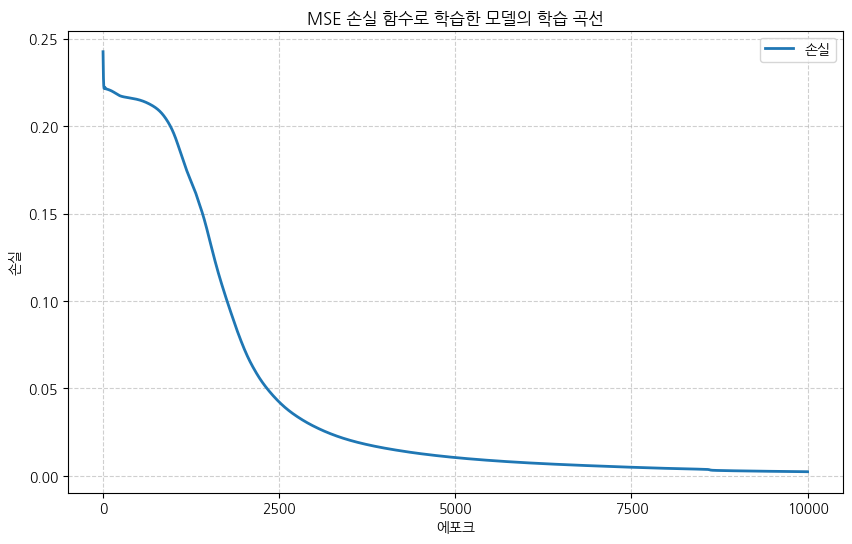

In [18]:
# 참고 - 학습 곡선 시각화 ([그림 3-11] 대응, EpochLogger 표준)
log_mse.plot(title='MSE 손실 함수로 학습한 모델의 학습 곡선')

## [코드 3-20] 평가 데이터로 평균제곱오차 손실 계산

모델 학습에 사용하지 않은 평가 데이터로 손실을 계산한다.

In [19]:
# 코드 3-20 - 평가 데이터로 평균제곱오차 손실 계산

model.eval()
with torch.no_grad():
    Y_pred_test = model(X_test)
    test_loss = criterion(Y_pred_test, Y_test_onehot)
    print(f'평가 데이터 손실: {test_loss.item()}')

평가 데이터 손실: 0.03965575248003006


## [코드 3-21] 모델 예측 결과의 형태

출력 텐서의 세 요소는 각 클래스에 대한 점수의 성격을 가진다.

In [20]:
# 코드 3-21 - 모델 예측 결과의 형태

model.eval()
test_sample = X_test[0]
with torch.no_grad():
    prediction = model(test_sample)                 # (3,)
    print(f'예측 결과: {prediction.tolist()}')

예측 결과: [0.9997400641441345, 0.0008381486986763775, 3.771664225382665e-08]


## [코드 3-22] 최댓값의 위치를 반환하는 `argmax()` 메서드

`argmax()` 는 최댓값의 위치만 반환한다. 최댓값이 둘 이상이면 첫 번째 위치를, 형태와 무관하게 일렬로 나열했을 때의 순서를 반환한다.

In [21]:
# 코드 3-22 - 최댓값의 위치를 반환하는 argmax() 메서드
tensor_1d = torch.tensor([10, 20, 30])
tensor_3d = torch.tensor([[[10, 20], [30, 7], [20, 66]],
                          [[35, 6], [66, 25], [4, 15]]])
print(f'tensor_1d 의 최댓값의 위치: {tensor_1d.argmax()}')        # 최댓값 30의 위치 인덱스
# torch.argmax(tensor) 함수 형태로 호출해도 됨
print(f'tensor_3d 의 최댓값의 위치: {torch.argmax(tensor_3d)}')   # 최댓값 66의 첫 번째 위치 인덱스

tensor_1d 의 최댓값의 위치: 2
tensor_3d 의 최댓값의 위치: 5


## [코드 3-23] 여러 샘플의 분류 결과를 한 번에 구하기

`dim=-1` 로 `argmax()` 를 호출하면 마지막 차원에서 최댓값의 위치를 집계해 여러 샘플의 분류 결과를 한 번에 구한다.

In [22]:
# 코드 3-23 - 여러 샘플의 분류 결과를 한 번에 구하기

model.eval()
test_samples = X_test[:5]
with torch.no_grad():
    predictions = model(test_samples)
    classes = predictions.argmax(dim=-1)
    print(f'분류 결과: {classes}')          # 다섯 샘플의 예측 클래스 텐서 출력

분류 결과: tensor([0, 0, 0, 0, 1])


## [코드 3-24] 평가 데이터의 분류 정확도 계산

분류 결과를 원래의 정답 레이블(`Y_test`) 과 비교해 정확도를 계산한다.

> 참고: 3장 본문의 `get_accuracy(model, X, Y)` 는 데이터로더가 아닌 텐서를 직접 입력받는 형태로 정의된다. `code_reference.common.get_accuracy()` 는 데이터로더용이므로 호출하지 않고 본문 정의를 그대로 노트북에 둔다.

In [23]:
# 코드 3-24 - 평가 데이터의 분류 정확도 계산

# 분류 정확도(백분율)를 계산해 반환하는 함수
def get_accuracy(model, X, Y):
    model.eval()
    with torch.no_grad():
        Y_pred = model(X)                       # 결과 예측 - (N, 3) 형태의 텐서
        classes = Y_pred.argmax(dim=-1)         # 분류 결과로 변환
        correct_count = (classes == Y).sum()
        accuracy = correct_count.item() / len(X) * 100.
        return accuracy


accuracy = get_accuracy(model, X_test, Y_test)
print(f'모델 분류 정확도: {accuracy:.2f}%')

모델 분류 정확도: 91.94%


## [코드 3-25] 로짓을 확률 분포로 변환

`F.softmax()` 함수 또는 `nn.Softmax` 계층으로 로짓을 0~1 사이의 확률 분포로 변환한다.

In [24]:
# 코드 3-25 - 로짓을 확률 분포로 변환

# F.softmax()로 로짓을 확률 분포로 변환
logit = torch.tensor([0.35, 0.05, 0.1])     # (3,) - 샘플 하나의 출력으로 가정
prob = F.softmax(logit, dim=-1)             # dim=-1: 마지막 차원을 기준으로 변환
print(f'logit 의 확률 분포: {prob}, 합계: {prob.sum()}')

# 여러 샘플을 한 번에 확률 분포로 변환할 수 있음 (F.softmax()도 가능)
# nn.Softmax 계층 객체를 사용해 로짓을 확률 분포로 변환
logits = torch.rand((2, 3))                 # (2, 3) - 두 샘플의 출력으로 가정
softmax_layer = nn.Softmax(dim=-1)          # 마지막 차원을 기준으로 변환
probs = softmax_layer(logits)
print(f'logits 의 샘플별 확률값의 합계: {probs.sum(dim=-1)}')

logit 의 확률 분포: tensor([0.3969, 0.2940, 0.3091]), 합계: 1.0
logits 의 샘플별 확률값의 합계: tensor([1., 1.])


## 교차 엔트로피 손실의 직관 — `-log(p)` 곡선

정답 클래스에 모델이 부여한 확률 `p` 가 1 에 가까우면 손실 `-log(p)` 는 0 에 가깝고, `p` 가 0 에 가까우면 손실이 가파르게 커진다. 교차 엔트로피가 '정답 클래스의 확률'에 집중해 학습을 이끄는 이유다.

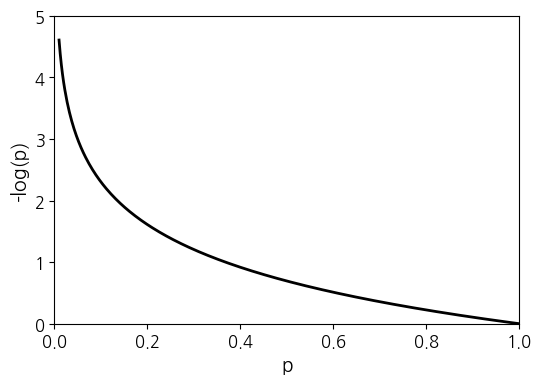

In [25]:
# [그림 3-12] - 교차 엔트로피 손실의 직관: -log(p) 곡선

import matplotlib.pyplot as plt

p = np.linspace(0.01, 1.0, 400)     # log(0) 을 피하려고 0.01 부터 시작
neg_log_p = -np.log(p)              # 자연로그 기준 -log(p)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(p, neg_log_p, color='black', linewidth=2)
ax.set_xlabel('p', fontsize=14)
ax.set_ylabel('-log(p)', fontsize=14)
ax.set_xlim(0, 1)
ax.set_ylim(0, 5)
ax.tick_params(labelsize=12)
viz._finalize(fig)                  

## [코드 3-26] 출력층 활성화 계층이 없는 분류 모델을 교차 엔트로피 손실 함수로 학습

마지막 활성화 계층을 제거하고 `nn.CrossEntropyLoss` 를 사용한다. 정답은 원-핫 벡터가 아닌 정수형 인덱스(`Y_train`) 로 전달한다.

In [26]:
# 코드 3-26 - 출력층 활성화 계층이 없는 분류 모델을 교차 엔트로피 손실 함수를 사용해 학습하기

# 손실 함수에 활성화 함수가 포함되어 있으므로 출력층에 활성화 함수를 사용하지 않음
layers_dict = OrderedDict([
    ('hidden_1', nn.Linear(2, HIDDEN_DIM)),
    ('activation_1', nn.Sigmoid()),
    ('hidden_2', nn.Linear(HIDDEN_DIM, HIDDEN_DIM)),
    ('activation_2', nn.Sigmoid()),
    ('output', nn.Linear(HIDDEN_DIM, 3)),
])

model_celoss = nn.Sequential(layers_dict)       # 모델 객체 생성
criterion = nn.CrossEntropyLoss()               # 교차 엔트로피 손실 함수
# 손실 함수는 재사용 가능하지만, 옵티마이저는 모델마다 따로 만들어야 함
optimizer = optim.Adam(model_celoss.parameters(), lr=LR)

log_celoss = train(model_celoss, X_train, Y_train, criterion, optimizer, EPOCHS)



      epoch         손실     시간
    1/10000       1.1312     0:00
 1000/10000       0.9054     0:01
 2000/10000       0.2394     0:02
 3000/10000       0.0893     0:03
 4000/10000       0.0503     0:04
 5000/10000       0.0334     0:06
 6000/10000       0.0236     0:07
 7000/10000       0.0169     0:08
 8000/10000       0.0120     0:09
 9000/10000       0.0085     0:10
10000/10000       0.0061     0:11


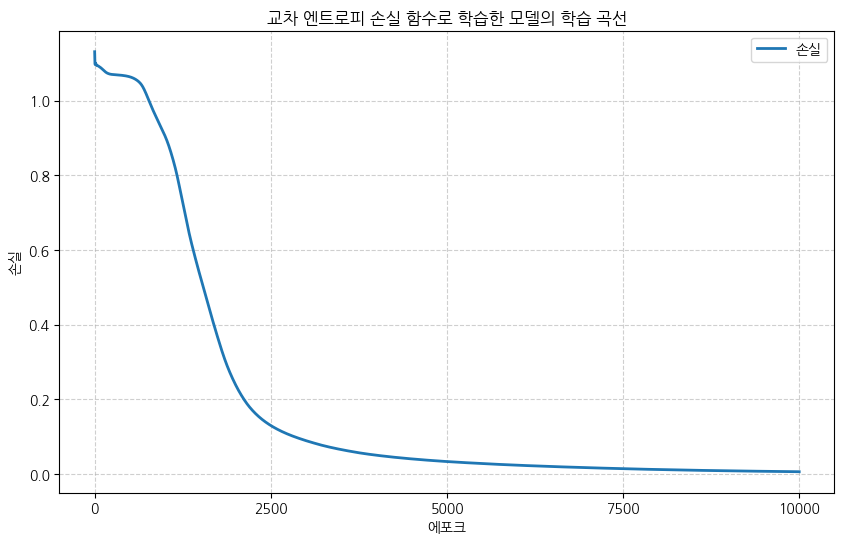

In [27]:
# 참고 - 교차 엔트로피 손실 함수로 학습한 모델의 학습 곡선

log_celoss.plot(title='교차 엔트로피 손실 함수로 학습한 모델의 학습 곡선')

## [코드 3-27] 교차 엔트로피 손실을 사용해 학습한 모델의 예측 결과

마지막 활성화가 없으므로 출력은 (소프트맥스를 통과하지 않은) 로짓이다.

In [28]:
# 코드 3-27 - 교차 엔트로피 손실을 사용해 학습한 모델의 예측 결과

test_sample = X_test[0]
model_celoss.eval()
with torch.no_grad():
    prediction = model_celoss(test_sample)
    print(f'예측 결과: {prediction.tolist()}')

예측 결과: [7.3967671394348145, -4.885035037994385, -7.288582801818848]


## [코드 3-28] 교차 엔트로피 손실을 사용해 학습한 모델의 정확도

로짓을 `argmax()` 로 분류 클래스로 변환하는 과정은 MSE 모델과 동일하다.

In [29]:
# 코드 3-28 - 교차 엔트로피 손실을 사용해 학습한 모델의 정확도
accuracy = get_accuracy(model_celoss, X_test, Y_test)
print(f'모델 분류 정확도: {accuracy:.2f}%')

모델 분류 정확도: 93.06%


## [그림 3-13] 대응 — MSE 와 교차 엔트로피 학습 곡선 비교

두 손실 함수는 계산 방법이 다르므로 직접 비교할 수 없지만, 형태 비교를 위해 0~1 범위로 정규화해 같은 축에 그린다.

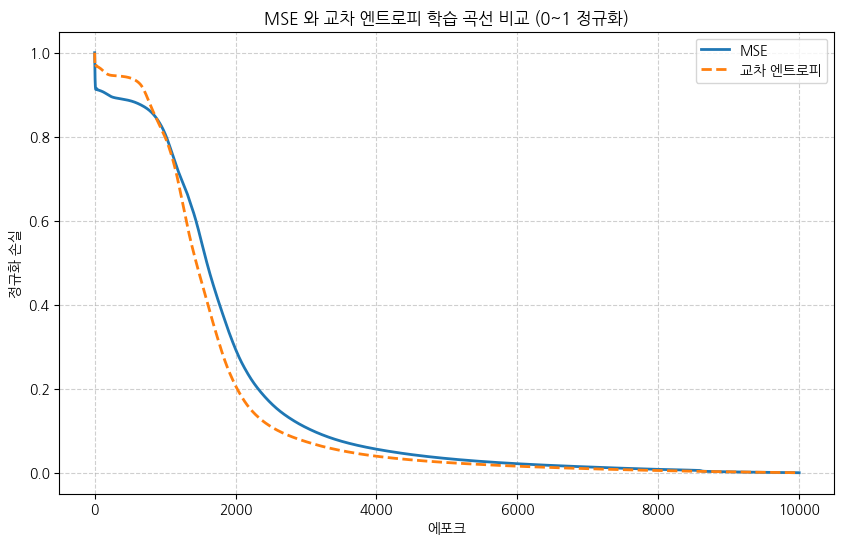

In [30]:
# [그림 3-13] - 두 학습 곡선을 0~1 범위로 정규화해 비교

losses = log_mse.history['손실']
losses_celoss = log_celoss.history['손실']

def normalize(arr):
    a = np.asarray(arr, dtype=float)
    return ((a - a.min()) / (a.max() - a.min())).tolist()


viz.plot_histories(
    {
        'MSE': normalize(losses),
        '교차 엔트로피': normalize(losses_celoss),
    },
    title='MSE 와 교차 엔트로피 학습 곡선 비교 (0~1 정규화)',
    y_label='정규화 손실',
)

## ReLU 활성화 함수 — `ReLU(x) = max(0, x)`

음수 입력은 0 으로 막고 양수 입력은 그대로 통과시키는 함수다. 시그모이드와 달리 양수 구간에서 기울기가 1 로 일정해 기울기 소실이 덜하다.

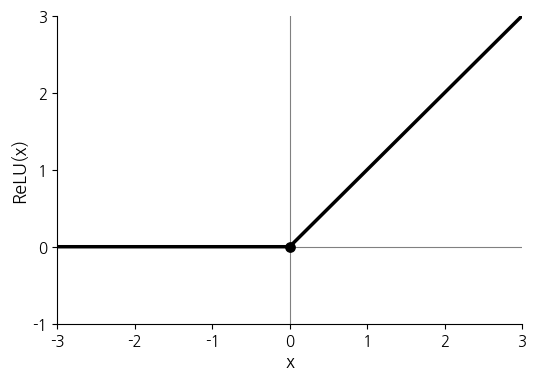

In [31]:
# [그림 3-14] - ReLU 활성화 함수 그래프

import matplotlib.pyplot as plt

x = np.linspace(-3, 3, 400)
relu = np.maximum(0, x)             # ReLU(x) = max(0, x)

fig, ax = plt.subplots(figsize=(6, 4))
ax.axhline(0, color='gray', linewidth=0.8)
ax.axvline(0, color='gray', linewidth=0.8)
ax.plot(x, relu, color='black', linewidth=2.5)
ax.scatter([0], [0], color='black', s=45, zorder=3)   # 꺾이는 지점 (0, 0)
ax.set_xlim(-3, 3)
ax.set_ylim(-1, 3)
ax.set_xticks(range(-3, 4))
ax.set_yticks(range(-1, 4))
ax.set_xlabel('x', fontsize=13)
ax.set_ylabel('ReLU(x)', fontsize=13)
ax.tick_params(labelsize=11)
ax.spines[['top', 'right']].set_visible(False)
viz._finalize(fig)

## [코드 3-29] ReLU 활성화 함수를 사용한 모델과 학습 결과

은닉층 사이의 `nn.Sigmoid()` 를 `nn.ReLU()` 로 교체한다. 손실 함수(교차 엔트로피) 와 출력 형태가 동일하므로 같은 방법으로 학습한다.

In [32]:
# 코드 3-29 - ReLU 활성화 함수를 적용해 만든 모델

# 은닉층의 Sigmoid 활성화 함수를 ReLU 활성화 함수로 교체한 다층 퍼셉트론 모델
layers_dict = OrderedDict([
    ('hidden_1', nn.Linear(2, HIDDEN_DIM)),
    ('activation_1', nn.ReLU()),
    ('hidden_2', nn.Linear(HIDDEN_DIM, HIDDEN_DIM)),
    ('activation_2', nn.ReLU()),
    ('output', nn.Linear(HIDDEN_DIM, 3)),
])

model_relu = nn.Sequential(layers_dict)         # 모델 객체 생성
optimizer = optim.Adam(model_relu.parameters(), lr=LR)
# 교차 엔트로피 손실 함수(nn.CrossEntropyLoss)를 재사용해 모델 학습
log_relu = train(
    model_relu, X_train, Y_train, criterion, optimizer, EPOCHS
)


      epoch         손실     시간
    1/10000       1.1152     0:00
 1000/10000       0.0648     0:01
 2000/10000       0.0322     0:02
 3000/10000       0.0225     0:03
 4000/10000       0.0170     0:04
 5000/10000       0.0132     0:05
 6000/10000       0.0105     0:06
 7000/10000       0.0084     0:07
 8000/10000       0.0068     0:08
 9000/10000       0.0057     0:09
10000/10000       0.0048     0:10


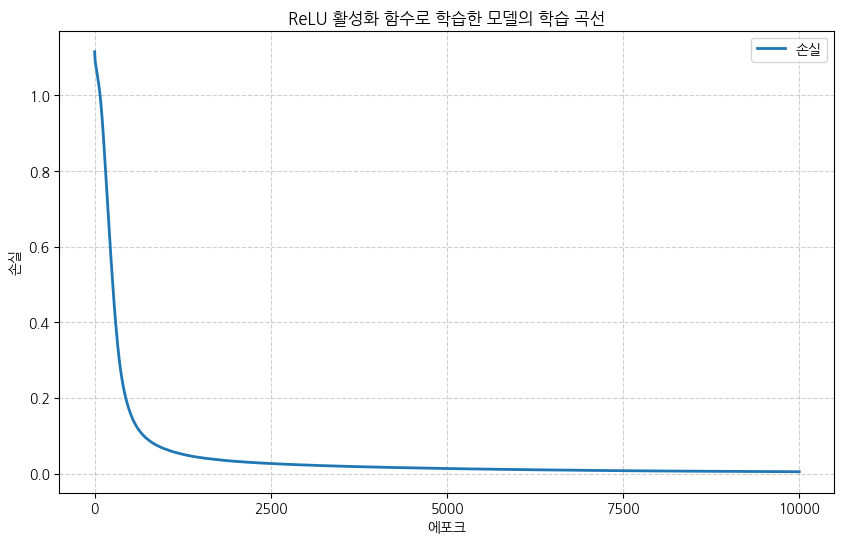

ReLU 모델 분류 정확도: 93.33%


In [33]:
# 참고 - ReLU 활성화 함수를 적용한 모델의 학습 곡선과 분류 정확도

log_relu.plot(title='ReLU 활성화 함수로 학습한 모델의 학습 곡선')

accuracy = get_accuracy(model_relu, X_test, Y_test)
print(f'ReLU 모델 분류 정확도: {accuracy:.2f}%')

## [그림 3-15] 대응 — 세 모델의 학습 곡선 비교

세 모델(MSE+시그모이드, 교차 엔트로피+시그모이드, 교차 엔트로피+ReLU) 의 학습 곡선을 0~1 범위로 정규화해 겹쳐 그린다.

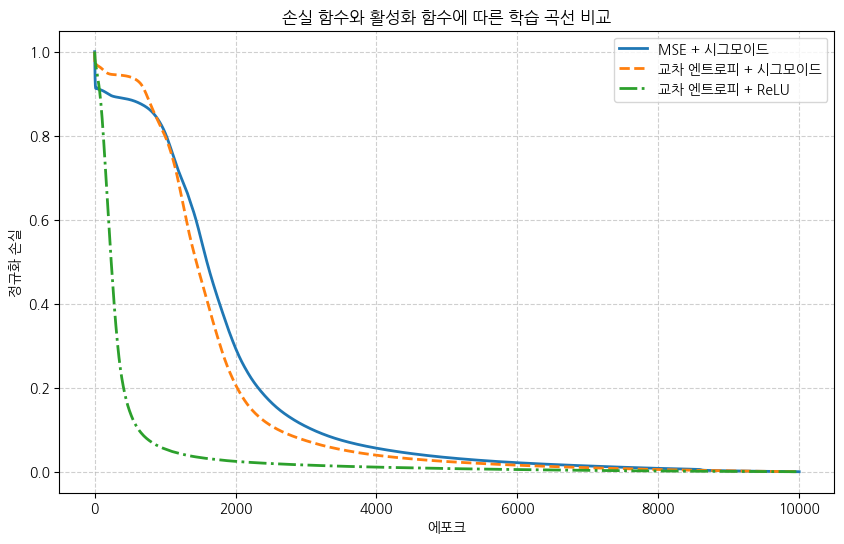

In [34]:
# [그림 3-15] - 세 모델 학습 곡선 비교 (0-1 범위로 정규화해 비교)
losses_relu = log_relu.history['손실']

viz.plot_histories(
    {
        'MSE + 시그모이드': normalize(losses),
        '교차 엔트로피 + 시그모이드': normalize(losses_celoss),
        '교차 엔트로피 + ReLU': normalize(losses_relu),
    },
    title='손실 함수와 활성화 함수에 따른 학습 곡선 비교',
    y_label='정규화 손실',
)

## 정리

본 절에서는 다음을 차례로 적용해 회오리 분류 모델의 성능을 개선했다.

1. **MSE + 시그모이드 활성화**
2. **교차 엔트로피 + 시그모이드 활성화** (마지막 활성화 계층 제거, 정수 인덱스 정답)
3. **교차 엔트로피 + ReLU 활성화** (은닉층 활성화를 ReLU 로 교체)

노트북 결과는 시드 42 기준이므로 본문 수치와 다를 수 있다. 학습 곡선 형태(특히 ReLU 의 빠른 수렴)는 본문 설명과 일관되게 관찰된다.

다음 4 장에서는 데이터를 다루는 본격적인 도구(데이터셋·데이터로더) 를 학습한다.